# Градиентный спуск и его модификации: Momentum, NAG, RMSprop

Несколько экспериментов с одномерной оптимизацией на чистом numpy. Сначала каждый метод
на своей функции (так они и были задуманы), а в конце — честное сравнение всех четырёх
на одной и той же.

Классический градиентный спуск:

$$x_{k+1} = x_k - \lambda \, f'(x_k)$$

У него две известные проблемы: на пологих участках градиент мал и сходимость ползёт,
а в «оврагах» начинаются осцилляции из стороны в сторону. Модификации ниже как раз
с этим борются:

- **Momentum** накапливает инерцию через экспоненциальное среднее градиентов:
  $v_k = \gamma v_{k-1} + (1-\gamma)\, \lambda f'(x_k)$, шаг $x_{k+1} = x_k - v_k$;
- **NAG** (ускорение Нестерова) — то же, но градиент считается в точке «забегания вперёд»
  $x_k - \gamma v_{k-1}$;
- **RMSprop** нормирует шаг на скользящее среднее квадратов градиентов:
  $G_k = \alpha G_{k-1} + (1-\alpha)(f'(x_k))^2$, шаг $\Delta x = \lambda f'(x_k) / (\sqrt{G_k} + \varepsilon)$.


## 1. Классический градиентный спуск

Функция $f(x) = 0.5x + 0.2x^2 - 0.1x^3$, старт $x_0 = -4$, шаг $\lambda = 0.01$.
Шаг специально взят маленький — интересно, куда успеем дойти за 200 итераций.


In [2]:
import numpy as np
import matplotlib.pyplot as plt


def func(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.1 * x ** 3


def df(x):
    return 0.5 + 0.4 * x - 0.3 * x ** 2


x = -4.0   # стартовая точка
lr = 0.01  # шаг обучения
N = 200    # число итераций

history = [x]
for _ in range(N):
    x = x - lr * df(x)
    history.append(x)

print(f"x* = {x:.4f}, f(x*) = {func(x):.4f}")


x* = -1.0759, f(x*) = -0.1819


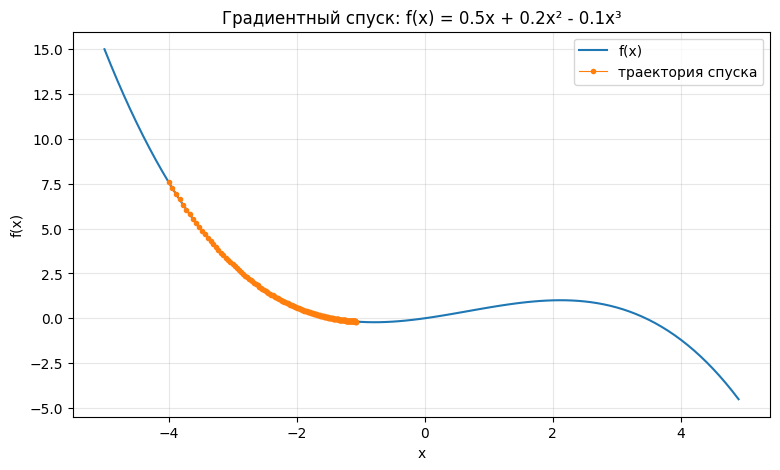

In [3]:
grid = np.arange(-5.0, 5.0, 0.1)
history_arr = np.array(history)

plt.figure(figsize=(9, 5))
plt.plot(grid, func(grid), label="f(x)")
plt.plot(history_arr, func(history_arr), "o-", ms=3, lw=0.8,
         label="траектория спуска")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Градиентный спуск: f(x) = 0.5x + 0.2x² - 0.1x³")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Спуск идёт в сторону локального минимума, но с шагом 0.01 за 200 итераций
до окрестности минимума просто не доходит — точка ползёт по пологому участку. Это ровно та
ситуация, где помогает инерция.

## 2. Momentum (метод импульсов)

Функция $f(x) = -0.5x + 0.2x^2 - 0.01x^3 - 0.3\sin 4x$, старт $x_0 = -3.5$,
$\gamma = 0.8$, $\lambda = 0.1$.


In [4]:
def func2(x):
    return -0.5 * x + 0.2 * x ** 2 - 0.01 * x ** 3 - 0.3 * np.sin(4 * x)


def df2(x):
    return -0.5 + 0.4 * x - 0.03 * x ** 2 - 1.2 * np.cos(4 * x)


x = -3.5
v = 0.0      # накапливаемый импульс
gamma = 0.8  # коэффициент затухания импульса
lr = 0.1
N = 200

history2 = [x]
for _ in range(N):
    v = gamma * v + (1 - gamma) * lr * df2(x)
    x = x - v
    history2.append(x)

print(f"x* = {x:.4f}, f(x*) = {func2(x):.4f}")


x* = 0.4606, f(x*) = -0.4778


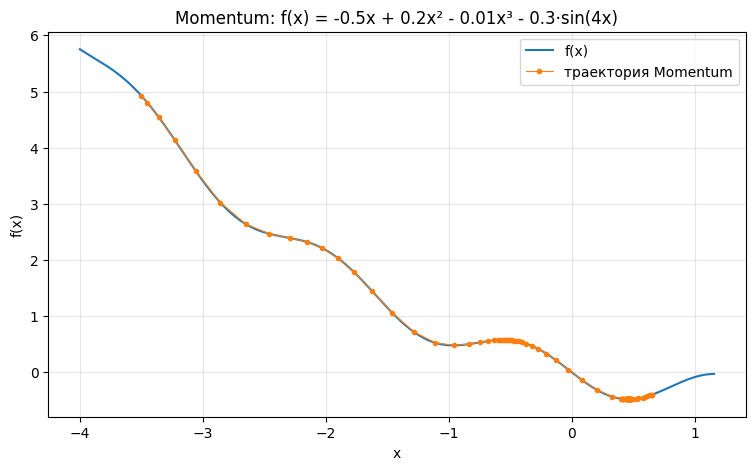

In [5]:
grid2 = np.linspace(min(history2) - 0.5, max(history2) + 0.5, 500)
history2_arr = np.array(history2)

plt.figure(figsize=(9, 5))
plt.plot(grid2, func2(grid2), label="f(x)")
plt.plot(history2_arr, func2(history2_arr), "o-", ms=3, lw=0.8,
         label="траектория Momentum")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Momentum: f(x) = -0.5x + 0.2x² - 0.01x³ - 0.3·sin(4x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


За счёт импульса точка разгоняется на спуске и проскакивает мелкие
локальные впадины, которые у обычного GD стали бы ловушкой. Плата за это — инерция
может протащить точку мимо минимума, и ей приходится возвращаться.

## 3. NAG — ускорение Нестерова

Та же идея инерции, но градиент вычисляется не в текущей точке, а в точке,
куда нас уже тащит импульс: $v_k = \gamma v_{k-1} + (1-\gamma)\lambda f'(x_k - \gamma v_{k-1})$.
Такая «подглядка вперёд» гасит осцилляции у минимума.

Функция $f(x) = 0.4x + 0.1\sin 2x + 0.2\cos 3x$, старт $x_0 = 4$, $\gamma = 0.7$, $\lambda = 1$.


In [6]:
def func3(x):
    return 0.4 * x + 0.1 * np.sin(2 * x) + 0.2 * np.cos(3 * x)


def df3(x):
    return 0.4 + 0.2 * np.cos(2 * x) - 0.6 * np.sin(3 * x)


x = 4.0
v = 0.0
gamma = 0.7
lr = 1.0
N = 500

history3 = [x]
for _ in range(N):
    # градиент считаем в точке «забегания вперёд» x - gamma * v
    v = gamma * v + (1 - gamma) * lr * df3(x - gamma * v)
    x = x - v
    history3.append(x)

print(f"x* = {x:.4f}, f(x*) = {func3(x):.4f}")


x* = 0.8117, f(x*) = 0.2724


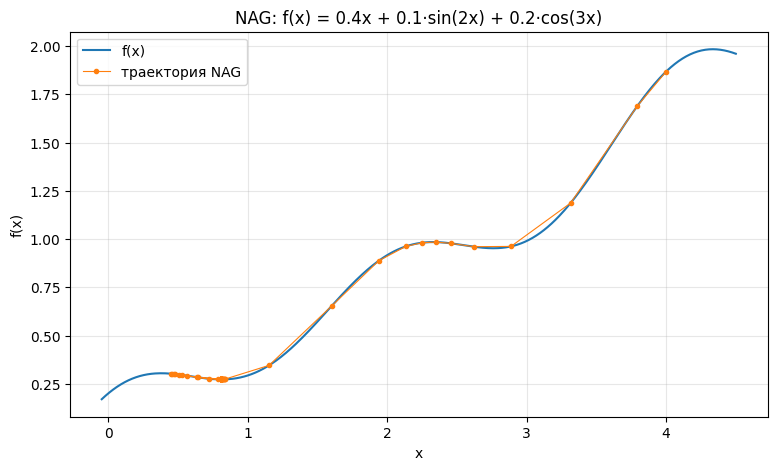

In [7]:
grid3 = np.linspace(min(history3) - 0.5, max(history3) + 0.5, 500)
history3_arr = np.array(history3)

plt.figure(figsize=(9, 5))
plt.plot(grid3, func3(grid3), label="f(x)")
plt.plot(history3_arr, func3(history3_arr), "o-", ms=3, lw=0.8,
         label="траектория NAG")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("NAG: f(x) = 0.4x + 0.1·sin(2x) + 0.2·cos(3x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. RMSprop

Здесь шаг подстраивается под масштаб градиента: $G_k$ — скользящее среднее квадратов
производной, и большие градиенты «приглушаются» делением на $\sqrt{G_k}$.

Функция $f(x) = 2x + 0.1x^3 + 2\cos 3x$, старт $x_0 = 4$, $\alpha = 0.8$, $\lambda = 0.5$,
$\varepsilon = 0.01$.


In [8]:
def func4(x):
    return 2 * x + 0.1 * x ** 3 + 2 * np.cos(3 * x)


def df4(x):
    return 2 + 0.3 * x ** 2 - 6 * np.sin(3 * x)


x = 4.0
G = 0.0      # скользящее среднее квадратов градиента
alpha = 0.8
lr = 0.5
eps = 0.01   # защита от деления на ноль
N = 200

history4 = [x]
for _ in range(N):
    G = alpha * G + (1 - alpha) * df4(x) ** 2
    x = x - lr * df4(x) / (np.sqrt(G) + eps)
    history4.append(x)

print(f"x* = {x:.4f}, f(x*) = {func4(x):.4f}")


x* = 0.6193, f(x*) = 0.6959


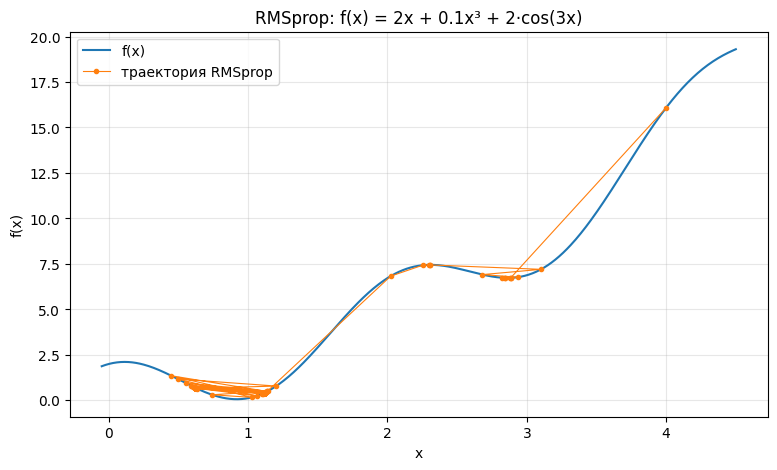

In [9]:
grid4 = np.linspace(min(history4) - 0.5, max(history4) + 0.5, 500)
history4_arr = np.array(history4)

plt.figure(figsize=(9, 5))
plt.plot(grid4, func4(grid4), label="f(x)")
plt.plot(history4_arr, func4(history4_arr), "o-", ms=3, lw=0.8,
         label="траектория RMSprop")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("RMSprop: f(x) = 2x + 0.1x³ + 2·cos(3x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 5. Сравнение на одной функции

У каждого метода выше была своя функция, поэтому сравнивать их «в лоб» по тем
экспериментам нечестно. Прогоню все четыре на простой параболе $f(x) = x^2$ из
одной стартовой точки $x_0 = 4$ — здесь минимум известен точно, и можно смотреть
только на скорость сходимости.


In [10]:
def f_bowl(x):
    return x ** 2


def df_bowl(x):
    return 2 * x


N = 50

# классический GD
x = 4.0
hist_gd = []
for _ in range(N):
    x = x - 0.1 * df_bowl(x)
    hist_gd.append(f_bowl(x))

# Momentum
x, v = 4.0, 0.0
hist_momentum = []
for _ in range(N):
    v = 0.8 * v + 0.2 * 0.1 * df_bowl(x)
    x = x - v
    hist_momentum.append(f_bowl(x))

# NAG
x, v = 4.0, 0.0
hist_nag = []
for _ in range(N):
    v = 0.8 * v + 0.2 * 0.1 * df_bowl(x - 0.8 * v)
    x = x - v
    hist_nag.append(f_bowl(x))

# RMSprop
x, G = 4.0, 0.0
hist_rmsprop = []
for _ in range(N):
    G = 0.8 * G + 0.2 * df_bowl(x) ** 2
    x = x - 0.3 * df_bowl(x) / (np.sqrt(G) + 0.01)
    hist_rmsprop.append(f_bowl(x))

print(f"{'итерация':>9} | {'GD':>12} | {'Momentum':>12} | {'NAG':>12} | {'RMSprop':>12}")
for k in (5, 10, 20, 50):
    print(f"{k:>9} | {hist_gd[k-1]:>12.3e} | {hist_momentum[k-1]:>12.3e} | "
          f"{hist_nag[k-1]:>12.3e} | {hist_rmsprop[k-1]:>12.3e}")


 итерация |           GD |     Momentum |          NAG |      RMSprop
        5 |    1.718e+00 |    5.387e+00 |    5.700e+00 |    3.651e+00
       10 |    1.845e-01 |    1.173e-01 |    3.336e-01 |    7.222e-01
       20 |    2.127e-03 |    2.306e-01 |    1.021e-01 |    4.479e-04
       50 |    3.259e-09 |    1.115e-04 |    3.198e-08 |    1.383e-01


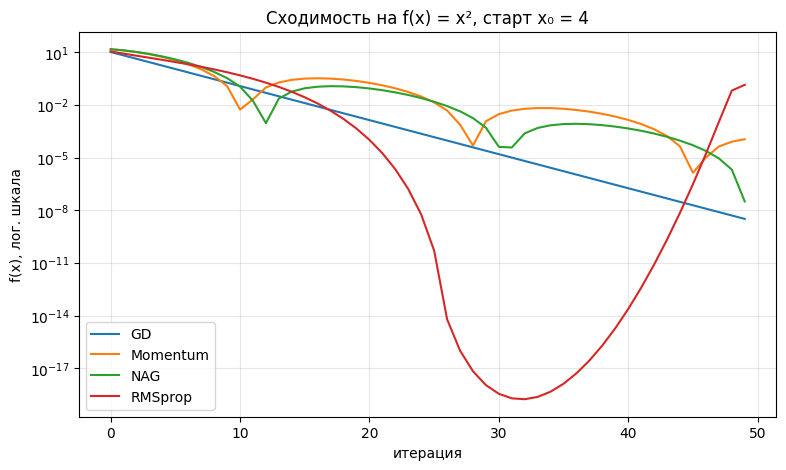

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(hist_gd, label="GD")
plt.plot(hist_momentum, label="Momentum")
plt.plot(hist_nag, label="NAG")
plt.plot(hist_rmsprop, label="RMSprop")
plt.yscale("log")
plt.xlabel("итерация")
plt.ylabel("f(x), лог. шкала")
plt.title("Сходимость на f(x) = x², старт x₀ = 4")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Выводы

- Классический GD прост и предсказуем, но сильно зависит от шага $\lambda$: маленький
  шаг — медленная сходимость, большой — осцилляции или расходимость.
- Momentum заметно ускоряет движение вдоль пологих направлений, но инерция
  провоцирует перелёт через минимум.
- NAG за счёт «подглядывания» вперёд входит в минимум аккуратнее, чем Momentum,
  при той же скорости разгона.
- RMSprop быстрее всех спускается к окрестности минимума, но вблизи него шаг не
  затухает (нормировка на $\sqrt{G_k}$ фактически фиксирует длину шага), поэтому точка
  не замирает в минимуме, а продолжает кружить рядом. На графике выше это видно
  по «рваному» хвосту кривой RMSprop. В нейросетевой практике это не мешает — там
  важна скорость, а не точная стоянка в минимуме.
- На мультимодальных функциях (синусоиды в примерах 2–4) все четыре метода находят
  локальный, а не глобальный минимум, и результат сильно зависит от стартовой точки.
  Никакая модификация GD от этого не спасает — это особенность постановки задачи.
